# ML for Gas Adsorption

## -1. Only if you run this notebook on Colab

If you use this notebook on Colab, please uncomment the lines below (remove the `#`) and execute the cell.

In [5]:
#import sys
#!{sys.executable} -m pip install -U pandas-profiling[notebook]
#!jupyter nbextension enable --py widgetsnbextension
#!pip install --upgrade pandas sklearn holoviews bokeh plotly matplotlib
#!wget https://raw.githubusercontent.com/kjappelbaum/ml_molsim/2022/descriptornames.py
#!mkdir data
#!cd data && wget https://github.com/kjappelbaum/ml_molsim/raw/2022/data/data.csv
#!cd data && wget https://github.com/kjappelbaum/ml_molsim/raw/2022/data/features.csv
# import os, holoviews as hv
# os.environ['HV_DOC_HTML'] = 'true'

## Import packages we will need

In [6]:
# basics
import os
import numpy as np
import pprint as pp

# pandas is used to read/process data
import pandas as pd

# machine learning dependencies
# scaling of data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# train/test split
from sklearn.model_selection import train_test_split
# model selection
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
# the KRR model
from sklearn.kernel_ridge import KernelRidge
# linear model
from sklearn.linear_model import LinearRegression
# pipeline to streamline modeling pipelines
from sklearn.pipeline import Pipeline
# principal component analysis
from sklearn.decomposition import PCA
# polynomial kernel
from sklearn.metrics.pairwise import polynomial_kernel
# Dummy model as baseline
from sklearn.dummy import DummyClassifier, DummyRegressor
# Variance Threshold for feature selection
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
# metrics to measure model performance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             mean_absolute_error, mean_squared_error, max_error)

# save/load models
import joblib

# For the permutation importance implementation
from joblib import Parallel
from joblib import delayed
from sklearn.metrics import check_scoring
from sklearn.utils import Bunch
from sklearn.utils import check_random_state
from sklearn.utils import check_array

# plotting
import matplotlib.pyplot as plt
%matplotlib inline
from pymatviz.scatter import density_scatter_with_hist as hist_density


RANDOM_SEED = 4242424242
DATA_DIR = 'data'
DATA_FILE = os.path.join(DATA_DIR, 'data.csv')

np.random.seed(RANDOM_SEED)


In [7]:

other_descriptors = ["CellV [A^3]"]

geometric_descriptors = [
    "Di",
    "Df",
    "Dif",
    "density [g/cm^3]",
    "total_SA_volumetric",
    "total_SA_gravimetric",
    "total_POV_volumetric",
    "total_POV_gravimetric",
]

linker_descriptors = [
    "f-lig-chi-0",
    "f-lig-chi-1",
    "f-lig-chi-2",
    "f-lig-chi-3",
    "f-lig-Z-0",
    "f-lig-Z-1",
    "f-lig-Z-2",
    "f-lig-Z-3",
    "f-lig-I-0",
    "f-lig-I-1",
    "f-lig-I-2",
    "f-lig-I-3",
    "f-lig-T-0",
    "f-lig-T-1",
    "f-lig-T-2",
    "f-lig-T-3",
    "f-lig-S-0",
    "f-lig-S-1",
    "f-lig-S-2",
    "f-lig-S-3",
    "lc-chi-0-all",
    "lc-chi-1-all",
    "lc-chi-2-all",
    "lc-chi-3-all",
    "lc-Z-0-all",
    "lc-Z-1-all",
    "lc-Z-2-all",
    "lc-Z-3-all",
    "lc-I-0-all",
    "lc-I-1-all",
    "lc-I-2-all",
    "lc-I-3-all",
    "lc-T-0-all",
    "lc-T-1-all",
    "lc-T-2-all",
    "lc-T-3-all",
    "lc-S-0-all",
    "lc-S-1-all",
    "lc-S-2-all",
    "lc-S-3-all",
    "lc-alpha-0-all",
    "lc-alpha-1-all",
    "lc-alpha-2-all",
    "lc-alpha-3-all",
    "D_lc-chi-0-all",
    "D_lc-chi-1-all",
    "D_lc-chi-2-all",
    "D_lc-chi-3-all",
    "D_lc-Z-0-all",
    "D_lc-Z-1-all",
    "D_lc-Z-2-all",
    "D_lc-Z-3-all",
    "D_lc-I-0-all",
    "D_lc-I-1-all",
    "D_lc-I-2-all",
    "D_lc-I-3-all",
    "D_lc-T-0-all",
    "D_lc-T-1-all",
    "D_lc-T-2-all",
    "D_lc-T-3-all",
    "D_lc-S-0-all",
    "D_lc-S-1-all",
    "D_lc-S-2-all",
    "D_lc-S-3-all",
    "D_lc-alpha-0-all",
    "D_lc-alpha-1-all",
    "D_lc-alpha-2-all",
    "D_lc-alpha-3-all",
]

metalcenter_descriptors = [
    "mc_CRY-chi-0-all",
    "mc_CRY-chi-1-all",
    "mc_CRY-chi-2-all",
    "mc_CRY-chi-3-all",
    "mc_CRY-Z-0-all",
    "mc_CRY-Z-1-all",
    "mc_CRY-Z-2-all",
    "mc_CRY-Z-3-all",
    "mc_CRY-I-0-all",
    "mc_CRY-I-1-all",
    "mc_CRY-I-2-all",
    "mc_CRY-I-3-all",
    "mc_CRY-T-0-all",
    "mc_CRY-T-1-all",
    "mc_CRY-T-2-all",
    "mc_CRY-T-3-all",
    "mc_CRY-S-0-all",
    "mc_CRY-S-1-all",
    "mc_CRY-S-2-all",
    "mc_CRY-S-3-all",
    "D_mc_CRY-chi-0-all",
    "D_mc_CRY-chi-1-all",
    "D_mc_CRY-chi-2-all",
    "D_mc_CRY-chi-3-all",
    "D_mc_CRY-Z-0-all",
    "D_mc_CRY-Z-1-all",
    "D_mc_CRY-Z-2-all",
    "D_mc_CRY-Z-3-all",
    "D_mc_CRY-I-0-all",
    "D_mc_CRY-I-1-all",
    "D_mc_CRY-I-2-all",
    "D_mc_CRY-I-3-all",
    "D_mc_CRY-T-0-all",
    "D_mc_CRY-T-1-all",
    "D_mc_CRY-T-2-all",
    "D_mc_CRY-T-3-all",
    "D_mc_CRY-S-0-all",
    "D_mc_CRY-S-1-all",
    "D_mc_CRY-S-2-all",
    "D_mc_CRY-S-3-all",
]

functionalgroup_descriptors = [
    "func-chi-0-all",
    "func-chi-1-all",
    "func-chi-2-all",
    "func-chi-3-all",
    "func-Z-0-all",
    "func-Z-1-all",
    "func-Z-2-all",
    "func-Z-3-all",
    "func-I-0-all",
    "func-I-1-all",
    "func-I-2-all",
    "func-I-3-all",
    "func-T-0-all",
    "func-T-1-all",
    "func-T-2-all",
    "func-T-3-all",
    "func-S-0-all",
    "func-S-1-all",
    "func-S-2-all",
    "func-S-3-all",
    "func-alpha-0-all",
    "func-alpha-1-all",
    "func-alpha-2-all",
    "func-alpha-3-all",
    "D_func-chi-0-all",
    "D_func-chi-1-all",
    "D_func-chi-2-all",
    "D_func-chi-3-all",
    "D_func-Z-0-all",
    "D_func-Z-1-all",
    "D_func-Z-2-all",
    "D_func-Z-3-all",
    "D_func-I-0-all",
    "D_func-I-1-all",
    "D_func-I-2-all",
    "D_func-I-3-all",
    "D_func-T-0-all",
    "D_func-T-1-all",
    "D_func-T-2-all",
    "D_func-T-3-all",
    "D_func-S-0-all",
    "D_func-S-1-all",
    "D_func-S-2-all",
    "D_func-S-3-all",
    "D_func-alpha-0-all",
    "D_func-alpha-1-all",
    "D_func-alpha-2-all",
    "D_func-alpha-3-all",
]


summed_linker_descriptors = [
    "sum-f-lig-chi-0",
    "sum-f-lig-chi-1",
    "sum-f-lig-chi-2",
    "sum-f-lig-chi-3",
    "sum-f-lig-Z-0",
    "sum-f-lig-Z-1",
    "sum-f-lig-Z-2",
    "sum-f-lig-Z-3",
    "sum-f-lig-I-0",
    "sum-f-lig-I-1",
    "sum-f-lig-I-2",
    "sum-f-lig-I-3",
    "sum-f-lig-T-0",
    "sum-f-lig-T-1",
    "sum-f-lig-T-2",
    "sum-f-lig-T-3",
    "sum-f-lig-S-0",
    "sum-f-lig-S-1",
    "sum-f-lig-S-2",
    "sum-f-lig-S-3",
    "sum-lc-chi-0-all",
    "sum-lc-chi-1-all",
    "sum-lc-chi-2-all",
    "sum-lc-chi-3-all",
    "sum-lc-Z-0-all",
    "sum-lc-Z-1-all",
    "sum-lc-Z-2-all",
    "sum-lc-Z-3-all",
    "sum-lc-I-0-all",
    "sum-lc-I-1-all",
    "sum-lc-I-2-all",
    "sum-lc-I-3-all",
    "sum-lc-T-0-all",
    "sum-lc-T-1-all",
    "sum-lc-T-2-all",
    "sum-lc-T-3-all",
    "sum-lc-S-0-all",
    "sum-lc-S-1-all",
    "sum-lc-S-2-all",
    "sum-lc-S-3-all",
    "sum-lc-alpha-0-all",
    "sum-lc-alpha-1-all",
    "sum-lc-alpha-2-all",
    "sum-lc-alpha-3-all",
    "sum-D_lc-chi-0-all",
    "sum-D_lc-chi-1-all",
    "sum-D_lc-chi-2-all",
    "sum-D_lc-chi-3-all",
    "sum-D_lc-Z-0-all",
    "sum-D_lc-Z-1-all",
    "sum-D_lc-Z-2-all",
    "sum-D_lc-Z-3-all",
    "sum-D_lc-I-0-all",
    "sum-D_lc-I-1-all",
    "sum-D_lc-I-2-all",
    "sum-D_lc-I-3-all",
    "sum-D_lc-T-0-all",
    "sum-D_lc-T-1-all",
    "sum-D_lc-T-2-all",
    "sum-D_lc-T-3-all",
    "sum-D_lc-S-0-all",
    "sum-D_lc-S-1-all",
    "sum-D_lc-S-2-all",
    "sum-D_lc-S-3-all",
    "sum-D_lc-alpha-0-all",
    "sum-D_lc-alpha-1-all",
    "sum-D_lc-alpha-2-all",
    "sum-D_lc-alpha-3-all",
]

summed_metalcenter_descriptors = [
    "sum-mc_CRY-chi-0-all",
    "sum-mc_CRY-chi-1-all",
    "sum-mc_CRY-chi-2-all",
    "sum-mc_CRY-chi-3-all",
    "sum-mc_CRY-Z-0-all",
    "sum-mc_CRY-Z-1-all",
    "sum-mc_CRY-Z-2-all",
    "sum-mc_CRY-Z-3-all",
    "sum-mc_CRY-I-0-all",
    "sum-mc_CRY-I-1-all",
    "sum-mc_CRY-I-2-all",
    "sum-mc_CRY-I-3-all",
    "sum-mc_CRY-T-0-all",
    "sum-mc_CRY-T-1-all",
    "sum-mc_CRY-T-2-all",
    "sum-mc_CRY-T-3-all",
    "sum-mc_CRY-S-0-all",
    "sum-mc_CRY-S-1-all",
    "sum-mc_CRY-S-2-all",
    "sum-mc_CRY-S-3-all",
    "sum-D_mc_CRY-chi-0-all",
    "sum-D_mc_CRY-chi-1-all",
    "sum-D_mc_CRY-chi-2-all",
    "sum-D_mc_CRY-chi-3-all",
    "sum-D_mc_CRY-Z-0-all",
    "sum-D_mc_CRY-Z-1-all",
    "sum-D_mc_CRY-Z-2-all",
    "sum-D_mc_CRY-Z-3-all",
    "sum-D_mc_CRY-I-0-all",
    "sum-D_mc_CRY-I-1-all",
    "sum-D_mc_CRY-I-2-all",
    "sum-D_mc_CRY-I-3-all",
    "sum-D_mc_CRY-T-0-all",
    "sum-D_mc_CRY-T-1-all",
    "sum-D_mc_CRY-T-2-all",
    "sum-D_mc_CRY-T-3-all",
    "sum-D_mc_CRY-S-0-all",
    "sum-D_mc_CRY-S-1-all",
    "sum-D_mc_CRY-S-2-all",
    "sum-D_mc_CRY-S-3-all",
]

summed_functionalgroup_descriptors = [
    "sum-func-chi-0-all",
    "sum-func-chi-1-all",
    "sum-func-chi-2-all",
    "sum-func-chi-3-all",
    "sum-func-Z-0-all",
    "sum-func-Z-1-all",
    "sum-func-Z-2-all",
    "sum-func-Z-3-all",
    "sum-func-I-0-all",
    "sum-func-I-1-all",
    "sum-func-I-2-all",
    "sum-func-I-3-all",
    "sum-func-T-0-all",
    "sum-func-T-1-all",
    "sum-func-T-2-all",
    "sum-func-T-3-all",
    "sum-func-S-0-all",
    "sum-func-S-1-all",
    "sum-func-S-2-all",
    "sum-func-S-3-all",
    "sum-func-alpha-0-all",
    "sum-func-alpha-1-all",
    "sum-func-alpha-2-all",
    "sum-func-alpha-3-all",
    "sum-D_func-chi-0-all",
    "sum-D_func-chi-1-all",
    "sum-D_func-chi-2-all",
    "sum-D_func-chi-3-all",
    "sum-D_func-Z-0-all",
    "sum-D_func-Z-1-all",
    "sum-D_func-Z-2-all",
    "sum-D_func-Z-3-all",
    "sum-D_func-I-0-all",
    "sum-D_func-I-1-all",
    "sum-D_func-I-2-all",
    "sum-D_func-I-3-all",
    "sum-D_func-T-0-all",
    "sum-D_func-T-1-all",
    "sum-D_func-T-2-all",
    "sum-D_func-T-3-all",
    "sum-D_func-S-0-all",
    "sum-D_func-S-1-all",
    "sum-D_func-S-2-all",
    "sum-D_func-S-3-all",
    "sum-D_func-alpha-0-all",
    "sum-D_func-alpha-1-all",
    "sum-D_func-alpha-2-all",
    "sum-D_func-alpha-3-all",
]


 $\color{DarkBlue}{\textsf{Short question}}$
- We declared a global variable to fix the random seed (`RANDOM_SEED`). Why did we do this?  

A fixed random seed (`RANDOM_SEED`) was declared in order to ensure the **reproducibility** of the results.
Several steps of the workflow, such as data shuffling during the train–test split, randomized parameter searches, or model initialization, involve stochastic processes. By setting a constant seed, these random operations are made deterministic, allowing the same data partitions and model outcomes to be obtained each time the code is executed. This practice facilitates consistent comparisons between experiments and simplifies debugging.

## Hands-on Project: Carbon-dioxide uptake in MOFs

In this exercise we will build a model that can predict the CO$_2$ uptake of metal-organic frameworks (MOFs), which are crystalline materials consisting of inorganic metal nodes linked by organic linkers.

![MOF building principle](assets/mof_building_principle.png)

There are two main **learning goals** for this exercise: 

1. Understand the typical workflow for machine learning in materials science. We will cover exploratory data analysis (EDA) and supervised learning (KRR).

2. Get familiar with some Python packages that are useful for data analysis and visualization. 

At the end of the exercise, you will produce an interactive plot like the one below, comparing the predictions of your model against CO$_2$ computed with GCMC simulations.
The histograms show the distributions of the errors on the training set (left) and on the test set (right).



<img src="assets/result.gif" alt="Parity interactive" width="700"/>

This exercise requires a basic knowledge of Python, e.g. that you can write list comprehensions, and are able to read documentation of functions provided by Python packages.
You will be asked to provide some function arguments (indicated by `#fillme` comments).

You can execute all the following code cells by pressing SHIFT and ENTER and get informations about the functions by pressing TAB when you are between the parentheses (see the notes for more tips). 

Also the [sklearn documentation](https://scikit-learn.org/stable/user_guide.html) is a great source of reference with many explanations and examples.

In pandas dataframe (df) you can select columns using their name by running `df[columnname]`. If at any point you think that the dataset is too large for your computer, you can select a subset using `df.sample()` or by making the test set larger in the train/test split (section 2). 

## 1. Import the data

In [8]:
df = pd.read_csv(DATA_FILE)

Let's take a look at the first few rows to see if everythings seems reasonable ...

In [9]:
df.head()

,ASA [m^2/cm^3],CellV [A^3],Df,Di,Dif,NASA [m^2/cm^3],POAV [cm^3/g],POAVF,PONAV [cm^3/g],PONAVF,...,pure_methane_widomHOA,pure_uptake_CO2_298.00_15000,pure_uptake_CO2_298.00_1600000,pure_uptake_methane_298.00_580000,pure_uptake_methane_298.00_6500000,logKH_CO2,logKH_CH4,CH4DC,CH4HPSTP,CH4LPSTP
0,2329.01,1251.28,6.61256,8.87694,8.48668,0.0,0.818919,0.68874,0.0,0.0,...,-8.144317,0.111981,14.218595,1.680640,9.163066,-5.125451,-5.511444,175.569974,215.005044,39.435070
1,1983.81,1254.01,5.80566,7.13426,7.13154,0.0,0.495493,0.58032,0.0,0.0,...,-10.208005,0.481625,9.312424,1.513152,5.908356,-4.502967,-5.505947,143.616349,193.059644,49.443295
2,2259.13,1250.58,5.99131,8.01682,7.98933,0.0,0.728036,0.65710,0.0,0.0,...,-8.479801,0.401683,14.796071,1.569714,7.933198,-4.433968,-5.525707,160.238808,199.765744,39.526937
3,1424.54,1249.27,4.73477,7.05822,7.05822,0.0,0.453157,0.47338,0.0,0.0,...,-12.615382,0.821747,10.816880,2.161833,6.710778,-4.135434,-5.297082,132.576623,195.582107,63.005483
4,2228.31,1250.61,6.40783,8.35944,8.26946,0.0,0.700539,0.65092,0.0,0.0,...,-8.743404,0.258905,14.153999,1.653013,8.272621,-4.774301,-5.515219,171.601539,214.452966,42.851427


<details>
<summary> <font color='green'>Click here for a hint</font></summary>
<ul>
    <li>Use something like <code>pd.options.display.max_columns=100</code> to adjust how many columns are shown.<code>pd.options.display.max_columns=100</code>  would show at maximum 100 columns. </li>
</ul>
</details>

Let's also get some basic information ...

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Columns: 343 entries, ASA [m^2/cm^3] to CH4LPSTP
dtypes: float64(342), object(1)
memory usage: 45.5+ MB


 $\color{DarkBlue}{\textsf{Short question}}$
- How many materials are in the dataset? 
- Which datatypes do we deal with?

***2.1) How many materials in dataset ?***


In [11]:
print(df["MOFname"].nunique())
print(len(df))
df["MOFname"].duplicated().any()


17379
17379


np.False_

After inspecting the dataset, the total number of rows (len(df) = 17379) matches exactly the number of unique material identifiers (MOFname.nunique() = 17379). This confirms what was found using the df.info() command. In addition, no duplicated entries were detected (duplicated().any() = False). This confirms that each row in the dataset corresponds to one unique material, and there are no repeated or missing`MOFname values.


*What duplicated().any() checks:*

df["MOFname"].duplicated() returns a Boolean Series that marks *True* for every row whose MOFname has already appeared earlier in the column (by default, it keeps the first occurrence as *False* and flags subsequent repeats as *True*). Applying .any() to that Series answers a yes/no question: *“Do any duplicates exist?”* If it returns *True*, at least one repeated MOFname is present; if it returns False,no duplicates are found.

***2.2) Which datatypes do we deal with***

From the df.info() output, the dataset consists of *343 columns* and *17,379 entries*. Among these columns, *342 are of type float64* and *one column is of type object*.

The float64 columns represent continuous numerical variables describing various *structural and physical properties* of each material, such as surface area (ASA), cell volume, density, pore volume (POAV), and other computed descriptors related to adsorption and framework geometry. These numerical values are suitable for quantitative analysis, statistical summaries, and machine learning models that require numeric input.

The single object column corresponds to *MOFname*, which contains the unique identifier or name of each material (e.g., str_m1_o10_o10_pcu_sym_102). This column serves as a *categorical/text attribute*, providing a label for each entry but not a numeric feature to be used directly in calculations.

In summary, the dataset is predominantly numerical, enabling quantitative modeling of material properties, while the lone text column (MOFname) functions as a key identifier linking each row to a specific material structure.


Below, we define three global variables (hence upper case), which are the *names* of our feature and target columns. We will use the `TARGET` for the actual regression and the `TARGET_BINARY` only for the stratified train/test split. The `FEATURES` variable is a list of column names of our dataframe.

In [12]:
TARGET = "pure_uptake_CO2_298.00_1600000"
TARGET_BINARY = "target_binned"  # will be created later
FEATURES = (
    geometric_descriptors
    + summed_functionalgroup_descriptors
    + summed_linker_descriptors
    + summed_metalcenter_descriptors
)


As descriptors we will use geometric properties such as density, pore volume, etc. and [revised autocorrelation functions](https://pubs.acs.org/doi/abs/10.1021/acs.jpca.7b08750) (RACs) that have been optimized for describing inorganic compounds ([and recently adapated for MOFs](https://www.nature.com/articles/s41467-020-17755-8))

Examples for pore geometry descriptors (in `geometric_descriptors`) include: $D_i$ (the size of the largest included sphere), $D_f$ (the largest free sphere), and $D_{if}$ (the largest included free sphere) along the pore $-$ three ways of characterizing pore size. 

![pore diameters](assets/spheres.png)

Also included are the surface area (SA) of the pore, and the probe-occupiable pore volume (POV).
More details on the description of pore geometries can be found in [Ongari et al.](https://pubs.acs.org/doi/abs/10.1021/acs.langmuir.7b01682)

RACs (in the lists starting with `summed_...`) operate on the structure graph and encode information about the metal center, linkers and the functional groups as differences or products of heuristics that are relevant for inorganic chemistry, such as electronegativity ($\chi$), connectivity ($T$), identity ($I$), covalent radii ($S$), and nuclear charge ($Z$).


<img src="assets/racs.png" alt="RACs scheme from the lecture" width="700"/>

The number in the descriptornames shows the coordination shell that was considered in the calculation of the RACs.

The target we use for this application is the high-pressure CO$_2$ uptake. This is the amount of CO$_2$ (mmol) the MOF can load per gram.

## 2. Split the data

Next, we split our data into a training set and a test set.

In order to prevent *any* information of the test set from leaking into our model, we split *before* starting to analyze or transform our data. For more details on why this matters, see [chapter 7.10.2 of Elements of Statistical Learning](https://web.stanford.edu/~hastie/ElemStatLearn//printings/ESLII_print10.pdf).

### 2.1. Split with stratification

[Stratification](https://en.wikipedia.org/wiki/Stratified_sampling) ensures that the class distributions (ratio of "good" to "bad" materials) are the same in the training and test set.

 $\color{DarkBlue}{\textsf{Short question}}$

- Why is this important? What could happen if we would not do this? 

Stratification is important when splitting a dataset into training and test sets because it ensures that the class distribution (for example, the ratio of “good” to “bad” materials) remains consistent across both subsets. This prevents one set from being overrepresented by one class, which could bias the model and lead to misleading performance metrics. Without stratification, a random split might produce an unbalanced dataset, for instance, if most high-performing materials end up in the training set and very few in the test set. In such a case, the model would appear to perform well during training but would fail to generalize to new, unseen data, making its evaluation unreliable.

Stratified sampling works by dividing the population into smaller, more homogeneous subgroups, or strata, based on shared characteristics, and then sampling proportionally from each group. This approach ensures that all relevant categories are properly represented in both the training and test sets, reducing sampling bias and increasing the accuracy and stability of the results. Compared to simple random sampling, stratification produces samples that better reflect the overall population and yield lower variance, which ultimately leads to a fairer and more consistent assessment of model performance.



For stratification to work, we to define what makes a "good" or a "bad" material. We will use 15 mmol CO$_2$ / g as the threshold for the uptake, thus binarizing our continuous target variable. (You can choose it based on the histogram of the variables)

 $\color{DarkBlue}{\textsf{Short Exercise}}$
 - add a column 'target_binary' that encodes whether a material is low performing (`0`) or high perfoming (`1`) by comparing the uptake with the `THRESHOLD`

<details>
<summary> <font color='green'>Click here for a hint</font></summary>
<ul>
    <li> you can use <a href='https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html'>pd.cut</a>, 
    <a href='https://stackoverflow.com/questions/4406389/if-else-in-a-list-comprehension'>list comprehension</a>, the <a href='https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.Binarizer.html#sklearn.preprocessing.Binarizer'> binarizer in sklearn </a>...) </li>
    <li> a list comprehension example: <code> [1 if value > THRESHOLD else 0 for value in df[TARGET]] </code> </li>
</ul>
</details>

In [13]:
THRESHOLD = 15 # in units of mmol CO2/g
df[TARGET_BINARY] = [1 if value > THRESHOLD else 0 for value in df[TARGET]]
print(df[TARGET_BINARY].value_counts())

target_binned
0    11422
1     5957
Name: count, dtype: int64


Now, we can perform the actual split into training and test set.

 $\color{DarkBlue}{\textsf{Short Exercise}}$
- select reasonable values for `XX` and `XY` and then perform the test/train splits. What do you consider when making this decision (think about what you would do with really small and really big datasets, what happens if you have only one test point, what happens to the model performance if you have more test points than training points)? 
- why do we need to perform the split into a training and test set? 
- would we use the test set to tune the hyperparameters of our model?

<details>
<summary> <font color='green'>Click here for a hint</font></summary>
<ul>
    <li>The `size` arguments can either be integers or, often more convenient, decimals like 0.1</li>
    <li>When you perform the split into training and test set you need to trade-off bias (pessimistic bias due to little training data) and variance (due to little test data) </li>
    <li>A typical split cloud be 70/30, but for huge dataset the test set might be too big and for small datasets the training set might be too small in this way </li>
</ul>
</details>

In [14]:
df_train_stratified, df_test_stratified = train_test_split(
    df,
    train_size=0.8,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=df[TARGET_BINARY],
)
print("Train size:", len(df_train_stratified), 
      " | Test size:", len(df_test_stratified))


Train size: 13903  | Test size: 3476


***5.1)***

For this dataset, which contains over 17,000 entries, a split of 80% for training and 20% for testing is appropriate. This ratio ensures that the model has enough data to learn meaningful patterns while still reserving a sufficiently large portion of data for evaluating its performance. In large datasets, even a smaller percentage (10–20%) still corresponds to thousands of samples, which provides a reliable and low-variance estimate of model performance.
For medium-sized datasets (around 1,000–10,000 samples), an 80/20 or 70/30 split is typically used. For small datasets (fewer than 1,000 samples), a 70/30 or 60/40 split is more suitable because the model needs more data to learn effectively. In these cases, cross-validation is also recommended to maximize the use of the available data. For very small datasets (under 100 samples), methods like leave-one-out or k-fold cross-validation are preferred instead of a single fixed split.

If there is only one test point, the model’s performance evaluation becomes meaningless. A single data point cannot represent the distribution of the dataset, and the resulting accuracy or error metric would be completely unreliable. For instance, if that one prediction is correct, the accuracy would be 100%, but if it is incorrect, it would be 0%. This produces an evaluation with extremely high variance and no statistical significance. A single point provides no real insight into how the model generalizes to new data.

If the test set is larger than the training set, the model will not have enough data to learn the underlying patterns in the data. This situation causes underfitting, where the model performs poorly on both the training and test sets because it cannot capture the complexity of the problem. While this setup might provide a precise estimate of how bad the model is, it does not help in building a useful predictive model. In general, the training set should always be larger than the test set to allow the model to learn effectively.

***5.2)***

The main purpose of splitting the dataset into training and test sets is to obtain an unbiased estimate of the model’s generalization performance, that is, how well it performs on unseen data. If the model were evaluated on the same data used for training, it would likely perform unrealistically well, since it has already been exposed to those examples. This leads to optimistic bias and overestimates the model’s true predictive ability. By setting aside a test set that the model never sees during training, we can more accurately measure how it will behave when applied to new, real-world data.

***5.3)***

No, the test set should never be used to tune hyperparameters. Hyperparameter tuning must be performed using only the training data, often through cross-validation. If the test set were used during this process, it would introduce data leakage meaning information from the test set would influence the model’s design, making the final evaluation biased and unreliable. The test set must be treated as completely unseen data and should only be used once, at the end of the project, to report the final model’s performance.

## 3. Exploratory data analysis (EDA) 

After we have put the test set aside, we can give the training set a closer look.

### 3.1. Correlations

 $\color{DarkBlue}{\textsf{Short Exercise}}$
- Plot some features against the target property and calculate the Pearson and Spearman correlation coefficient (what is the different between those correlation coefficients?) 
- What are the strongest correlations? Did you expect them? 
- What can be a problem when features are correlated?
- *Optional:* Do they change if you switch from CO$_2$ to CH$_4$ uptake as the target instead? Explain your observation.

To get the correlation matrices, you can use the `df.corr(method=)`method on your dataframe (`df`). You might want to calculate not the full correlation matrix but just the correlation of the features with the targets

<details>
<summary> <font color='green'>Click here for a hint</font></summary>
<ul>
    <li> To get the correlation with a target, you can use indexing. E.g. <code>df.corr(method='spearman')[TARGET]</code></li>
    <li> use <code>.sort_values()</code> method on the output of `df.corr()` to sort by the value of the correlation coefficient  </li>
      <li> You can use something like <code>scatter = hv.Scatter(df, 'Di', [TARGET,  'density [g/cm^3]']).opts(color='density [g/cm^3]', cmap='rainbow')</code> for plotting. Also consider the <a href="https://holoviews.org/reference/elements/matplotlib/Scatter.html"> <code>holoviews</code> documentation</a>. In case <code>holoviews</code> is too new for you, you can of course just use <code>matplotlib</code> and something like <code>plt.scatter(x,y)</code> </li>
</ul>
</details>

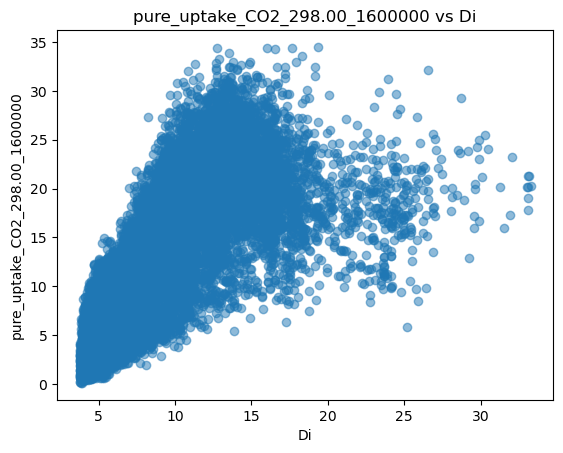

In [15]:
import pandas as pd


df[TARGET] = pd.to_numeric(df[TARGET], errors='coerce')

num_df = df.select_dtypes(include='number')

assert TARGET in num_df.columns, f"{TARGET} is not numeric."

import matplotlib.pyplot as plt

x_feat = 'Di'  
plt.scatter(df[x_feat], df[TARGET], alpha=0.5)
plt.xlabel(x_feat)
plt.ylabel(TARGET)
plt.title(f'{TARGET} vs {x_feat}')
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 8        
plt.rcParams["axes.titlesize"] = 8  
plt.rcParams["axes.labelsize"] = 9   
plt.rcParams["xtick.labelsize"] = 8  
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["legend.fontsize"] = 8


plt.show()


***Di vs pure CO2 uptake plot analysis***

From the plot, we observe a general positive correlation between Di and CO₂ uptake. As the pore diameter increases, the CO₂ uptake tends to rise, especially for smaller Di values between approximately 3 and 15 Å. This trend suggests that larger pore openings facilitate easier diffusion and adsorption of CO₂ molecules, up to a certain threshold.
However, the relationship is not perfectly linear. Beyond a certain Di value (around 15–20 Å), the CO₂ uptake appears to saturate and scatter, indicating that further increases in pore diameter do not necessarily lead to higher uptake. This plateau behavior is consistent with physical expectations. Once the pores are sufficiently large to accommodate CO₂ molecules, other factors such as surface area, pore volume, and adsorption energy become more influential.
Overall, this plot demonstrates that Di plays a significant but non-dominant role in determining CO₂ uptake, showing a positive but saturating relationship characteristic of many adsorption phenomena.

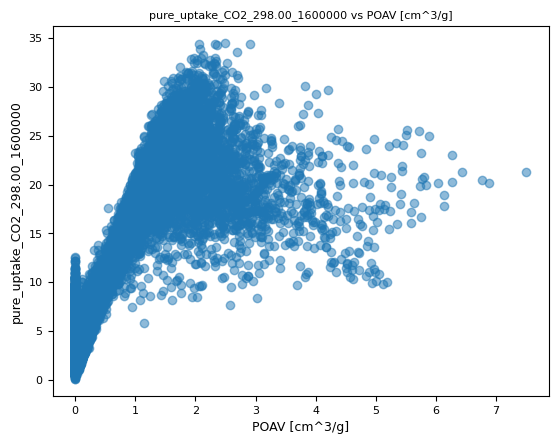

In [16]:
import pandas as pd


df[TARGET] = pd.to_numeric(df[TARGET], errors='coerce')

num_df = df.select_dtypes(include='number')

assert TARGET in num_df.columns, f"{TARGET} is not numeric."

import matplotlib.pyplot as plt

x_feat = 'POAV [cm^3/g]'  
plt.scatter(df[x_feat], df[TARGET], alpha=0.5)
plt.xlabel(x_feat)
plt.ylabel(TARGET)
plt.title(f'{TARGET} vs {x_feat}')
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 8        
plt.rcParams["axes.titlesize"] = 8  
plt.rcParams["axes.labelsize"] = 9   
plt.rcParams["xtick.labelsize"] = 8  
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["legend.fontsize"] = 8


plt.show()


***POAV vs pure CO2 uptake plot analysis***

A strong positive correlation is observed between POAV and CO₂ uptake, particularly at lower POAV values. Materials with a larger pore volume tend to have a higher CO₂ adsorption capacity, as greater internal void space allows for more gas molecules to be accommodated. The dense clustering of points at low POAV values, followed by a steady upward trend, supports this relationship.
However, beyond a POAV value of approximately 2–3 cm³/g, the relationship begins to flatten and become more dispersed. This suggests a saturation effect, where increasing pore volume further does not proportionally increase CO₂ uptake. This behavior can be attributed to the fact that extremely large pores contribute less to adsorption efficiency since the interaction energy between CO₂ molecules and pore walls weakens as the pore size increases.
In summary, CO₂ uptake increases rapidly with pore volume at small to moderate POAV values, but the effect diminishes at higher volumes. This confirms that while pore volume is a key descriptor for adsorption capacity, it interacts with other structural factors such as surface area and pore size distribution to determine overall CO₂ performance.

***6.1)***

The Pearson correlation coefficient measures the strength and direction of a linear relationship between two continuous variables. It assumes that both variables are normally distributed and that their relationship is linear. In contrast, the Spearman correlation coefficient is a rank-based (non-parametric) measure that captures monotonic relationships, whether linear or not. Spearman works by ranking the data points and then calculating the Pearson correlation on the ranks, making it less sensitive to outliers and non-linear patterns. In summary, Pearson is ideal for linear dependencies, while Spearman is more robust when the relationship is monotonic but potentially non-linear.

In [17]:
num_df = df.select_dtypes(include='number')
pearson  = num_df.corr(method='pearson')[TARGET].sort_values(ascending=False)
spearman = num_df.corr(method='spearman')[TARGET].sort_values(ascending=False)

print("Top 10 Pearson correlations with", TARGET, ":\n", pearson.head(10), "\n")
print("Top 10 Spearman correlations with", TARGET, ":\n", spearman.head(10))

Top 10 Pearson correlations with pure_uptake_CO2_298.00_1600000 :
 pure_uptake_CO2_298.00_1600000        1.000000
total_SA_gravimetric                  0.925695
pure_uptake_methane_298.00_6500000    0.921189
total_POV_volumetric                  0.916252
CH4DC                                 0.908832
POAVF                                 0.883668
target_binned                         0.857543
total_SA_volumetric                   0.847655
ASA [m^2/cm^3]                        0.827529
pure_methane_widomHOA                 0.815255
Name: pure_uptake_CO2_298.00_1600000, dtype: float64 

Top 10 Spearman correlations with pure_uptake_CO2_298.00_1600000 :
 pure_uptake_CO2_298.00_1600000        1.000000
pure_uptake_methane_298.00_6500000    0.967262
total_POV_gravimetric                 0.956879
total_SA_gravimetric                  0.953690
total_POV_volumetric                  0.940159
CH4DC                                 0.936276
POAV [cm^3/g]                         0.923432
POAVF      

***6.2)***

The table above lists the top ten features most strongly correlated with the CO₂ uptake at 298 K and 1600000 Pa. Both *Pearson* and *Spearman* correlation coefficients were calculated to assess linear and monotonic relationships, respectively.

The results show that *surface area*, *pore volume*, and *methane uptake* are the features most strongly correlated with CO₂ uptake, with correlation coefficients above 0.9 in both methods. This indicates that materials with a larger total surface area (SA) and pore volume (POV) tend to exhibit higher CO₂ adsorption capacities. Similarly, a high correlation with methane uptake suggests that materials capable of adsorbing one gas efficiently also tend to perform well for the other, due to similar adsorption mechanisms in porous structures.

The Pearson coefficients measure *linear* dependence, while Spearman coefficients assess *monotonic* relationships (i.e., consistent increase or decrease, not necessarily linear). The near-identical ranking and magnitudes of both sets of coefficients imply that the relationships between CO₂ uptake and these structural descriptors are largely linear and monotonic, with no major nonlinear trends or outliers dominating the data.

These results are expected because materials with larger accessible surface areas and greater pore volumes can adsorb more gas molecules, which directly increases the CO₂ uptake capacity. On the other hand, some features like density or metal center descriptors may show weaker or even negative correlations, as denser frameworks often have less pore space available for gas adsorption.
Thus, the observed strong correlations align with the physical intuition that gas adsorption is largely governed by pore geometry and available surface area.

In summary, this correlation analysis highlights that porosity-related descriptors (such as surface area and pore volume) are the dominant factors governing CO₂ uptake performance across the dataset, consistent with physical expectations for adsorption-driven processes.


***6.3)***

When features are strongly correlated with each other, the dataset suffers from multicollinearity. This means that some features provide overlapping or redundant information. In linear models such as regression, multicollinearity can cause the estimated coefficients to become unstable and highly sensitive to small variations in the data. It can also make it difficult to interpret which feature is truly influencing the target, as their effects may be entangled. Moreover, in machine learning models, redundant features can lead to overfitting, where the model learns noise instead of meaningful relationships, reducing its generalization performance.
Feature selection techniques or dimensionality reduction methods such as Principal Component Analysis (PCA) are often used to address this problem.

***6.4)***

If the target is changed from CO₂ uptake to CH₄ uptake, the correlations may change slightly in magnitude but often remain similar in trend. Both gases are adsorbed in the porous structures of the materials, so their uptakes depend on similar physical features such as surface area and pore volume. However, differences in molecular size, polarity, and interaction strength can lead to subtle differences in which features dominate. For example, CO₂ is more polarizable and interacts more strongly with functional groups or open metal sites, while CH₄ uptake may depend more on total pore volume and less on chemical composition. As a result, correlations for CH₄ might be slightly weaker and less sensitive to functional group descriptors compared to CO₂.

## 4. Baselines

For machine learning, it is important to have some *baselines* to which one then compares the results of a model. Think of a classification model for some rare disease where we only have 1% postives. A classification model that only predictes the negatives *all the time* will still have a amazingly high accuracy. To be able to understand if our model is really better than such a simple prediction we need to make the simple prediction first. This is what we call a baseline.

A baseline could be a really simple model, a basic heuristic or the current state of the art.
this. We will use a heuristic.

For this we use sklearn `Dummy` objects that simply calculate the mean, the median or the most frequent case of the training set, when you run the `fit()` method on them (which takes the features matrix $\mathbf{X}$ and the labels $\mathbf{y}$ as arguments.
This is, the prediction of a `DummyRegressor` with `mean` strategy will always be the mean, independent of the input (it will not look at the feature matrix!). 

Instead of using those `sklearn` objects you could also just manually compute the the mean or median of the dataset. But we will use those objects as we can learn in this way how to use estimators in `sklearn` and it is also allows you to test your full pipeline with different (baseline) models. 
What does this mean? In practice this means that you can use all the regression and classification models shown in the figure below in the same way, they will all have a `fit()` method that accepts `X` and `y` and a predict method that accepts `X` and returns the predictions. 


<img src="https://scikit-learn.org/1.3/_static/ml_map.png" alt="ML Map" width="800"/>

The estimator objects can be always used in the same way 

<img src="https://static.packt-cdn.com/products/9781789800265/graphics/d49a2e95-8f22-42ed-89f1-474b3d028787.png" alt="ML Map" width="400"/>

Using these objects, instead of the mean directly, allows you to easily swap them with other models in pipelines, where one chains many data transformation steps (see section 6).

### 4.1. Build dummy models

$\color{DarkBlue}{\textsf{Short Question}}$
- If you call `.fit(X, y)` on a `DummyRegressor` does it actually use the `X`? If not, why is there still the place for the `X` in the function? If yes, how does it use it?



**Short answer:** for the usual strategies (`"mean"`, `"median"`, `"quantile"`, `"constant"`), `DummyRegressor` **does not use the feature values in `X` to learn any relationship** with `y`. It estimates a *target-only* statistic from `y` (e.g., the mean) and later **always predicts that same value** for any input.

**Why `X` is still required in `.fit(X, y)`:**

* **API consistency with scikit-learn.** All estimators implement `fit(X, y)` (and often `predict(X)`), so `DummyRegressor` must keep the same signature to plug seamlessly into **`Pipeline`**, **`GridSearchCV`/`RandomizedSearchCV`**, and **cross-validation** tools.
* **Input validation and bookkeeping.** During `fit`, the estimator checks that the **number of samples** in `X` and `y` match and stores attributes such as:

  * `n_features_in_` (the number of features/columns in `X`) so that later `predict(X_new)` can **validate** that `X_new` has the same feature count.
  * output shape information (`n_outputs_`) for **multi-output** targets.
* **Predict-time shape:** at `predict(X_new)`, the regressor needs `X_new.shape[0]` to return the correct **number of predictions** (one row per input), even though the predicted values themselves do not depend on the features.

**What is *actually* learned in `.fit`:**

* For `strategy="mean"`: it computes the (possibly **weighted**) mean of `y` (if `sample_weight` is provided, the mean is weighted).
* For `strategy="median"`: it computes the (possibly **weighted**) median of `y`.
* For `strategy="quantile"`: it computes the specified quantile of `y` (again honoring `sample_weight`).
* For `strategy="constant"`: it simply stores the **user-provided constant** as the fitted value.
* For **multi-output** targets `y` with shape `(n_samples, n_outputs)`, the statistic is computed **per output column**, so predictions have shape `(n_samples, n_outputs)` with one constant per output.

**How `X` is (not) used mathematically:**

* No columns of `X` enter any formula; no coefficients or kernel weights are learned from `X`.
* `X` is used **only for validation and shape tracking**: matching sample counts during `fit`, storing `n_features_in_`, and ensuring at `predict` that the number of features matches what was seen during fitting; it also uses `len(X_new)` to produce that many rows of the constant prediction.

**Why having a `DummyRegressor` is useful:**

* It provides a **baseline**: a minimal model that ignores `X`. If a more complex model cannot beat the dummy (on **test** metrics like MAE/MSE/Max error), then the complex model likely overfits or the features carry little information.
* It integrates into the same evaluation/tuning workflow as real models thanks to the consistent `fit/predict` API.

**Conclusion:** `DummyRegressor.fit(X, y)` **requires** `X` for interface compatibility and validation but **does not use** the feature values to learn a mapping; it learns only a statistic of `y` (optionally with `sample_weight`) and then repeats that statistic for any input at prediction time.

$\color{DarkBlue}{\textsf{Short Exercise}}$
- Create [`DummyRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html) instances for  `mean`, `median`. (e.g. `dummyinstance = DummyRegressor(strategy='mean')`)
- Train them on the training data (`dummyinstance.fit(df_train[FEATURES], df_train[TARGET])`)



<details>
<summary> <font color='green'>Click here for hints</font></summary>
<ul>
    <li> to create <code>DummyRegressor</code> you can for example use <code> dummyregressor_mean = DummyRegressor(strategy='mean') </code> </li>
    <li> to see the implementation of the <code>DummyRegressor</code> you can check out <a href="https://github.com/scikit-learn/scikit-learn/blob/73732e5a0bc9b72c7049dc699d69aaedbb70ef0a/sklearn/dummy.py#L391"> the source code on GitHub</a> </li>
</ul>
</details>

In [18]:
# Build DummyRegressors
dummyregressor_mean = DummyRegressor(strategy='mean')
dummyregressor_median = DummyRegressor(strategy='median')

In [19]:
# Fit Dummy Regressors
dummyregressor_mean.fit(df_train_stratified[FEATURES], df_train_stratified[TARGET])
dummyregressor_median.fit(df_train_stratified[FEATURES], df_train_stratified[TARGET])

,strategy,'median'
,constant,None
,quantile,None


#### Evaluate the performance of the dummy models

 $\color{DarkBlue}{\textsf{Short Exercise}}$
- Calculate maximum error, mean absolute error and mean square error for the dummy regressors on training and test set. What would you expect those numbers to be?
- Do the actual values surprise you? 
- What does this mean in practice for reporting of metrics/the reasoning behind using baseline models

It can be handy to store our metrics of choice in a nested dictionary ([Python dictionaries are key-value pairs](https://www.tutorialspoint.com/python/python_dictionary.htm)): 

```python
{
    'dummyestimator1': {
                        'metric_a_key': metric_a_value, 
                        'metric_b_key': metric_b_value
                    },
    'dummyestimator2': {
                        'metric_a_key': metric_a_value, 
                        'metric_b_key': metric_b_value
                    },
 }
``` 

You will now write functions `get_regression_metrics(model, X, y_true)` that compute the metrics and return this dictionary for a given model. The `predict` method takes the feature matrix $\mathbf{X}$ as input.

In them, we calculate 

$\mathrm {MAE} =\frac{\sum _{i=1}^{n}\left|Y_{i}-\hat{y}_{i}\right|}{n}.$

and 

$\mathrm {MSE} = {\frac {1}{n}}\sum _{i=1}^{n}(Y_{i}-{\hat {Y_{i}}})^{2}.$ 

where $\hat{y}$ are the predictions and, $Y_{i}$ the true values.

as well as the maximum error.

<details>
<summary> <font color='green'>Click here for hints</font></summary>
<ul>
    <li> to perform a prediction using a estimator object, you can call <code> classifier.predict(X) </code> </li>
    <li> to calculate metrics, you can for example call <code>accuracy_score(true_values, predicted_values) </code> </li>
</ul>
</details>

In [20]:
def get_regression_metrics(model, x, y_true):
    """
    Get a dictionary with regression metrics.

    model : sklearn regressor with a predict method
    x     : feature matrix
    y_true: ground-truth labels (array-like)
    """
    # predictions
    y_predicted = model.predict(x)

    # metrics
    mae = mean_absolute_error(y_true, y_predicted)
    mse = mean_squared_error(y_true, y_predicted)
    maximum_error = max_error(y_true, y_predicted)

    # return in a nested-dict-friendly format
    metrics_dict = {
        'mae': mae,
        'mse': mse,
        'max_error': maximum_error
    }
    return metrics_dict


In [21]:
dummy_regressors = [
    ('mean', dummyregressor_mean),
    ('median', dummyregressor_median)
]

In [22]:
# initialize empty dictionaries
dummy_regressor_results_test = {}
dummy_regressor_results_train = {}

# pick the right test dataframe name automatically
_test_df = globals().get('df_test_stratified', globals().get('df_test'))
if _test_df is None:
    raise NameError("Neither df_test nor df_test_stratified found. Please define your test dataframe.")

# Prepare X/y for both splits (keep your FEATURE/TARGET naming)
X_train_eval = df_train_stratified[FEATURES]
y_train_eval = df_train_stratified[TARGET]

X_test_eval  = _test_df[FEATURES]
y_test_eval  = _test_df[TARGET]

# loop over the dummy_regressor list
for regressorname, regressor in dummy_regressors:
    print(f"Calculating metrics for {regressorname}")

    # TEST
    dummy_regressor_results_test[regressorname] = get_regression_metrics(
        regressor, X_test_eval, y_test_eval
    )

    # TRAIN
    dummy_regressor_results_train[regressorname] = get_regression_metrics(
        regressor, X_train_eval, y_train_eval
    )

# Pretty print (optional)
print("\n=== TRAIN metrics ===")
for k, v in dummy_regressor_results_train.items():
    print(k, v)

print("\n=== TEST  metrics ===")
for k, v in dummy_regressor_results_test.items():
    print(k, v)


Calculating metrics for mean
Calculating metrics for median

=== TRAIN metrics ===
mean {'mae': 6.333027169434022, 'mse': 54.358316750106916, 'max_error': 22.69371401465515}
median {'mae': 6.256700923073538, 'mse': 56.357359977037916, 'max_error': 24.1075892662}

=== TEST  metrics ===
mean {'mae': 6.23570655480622, 'mse': 52.37955580408542, 'max_error': 20.950406086755144}
median {'mae': 6.15904320182382, 'mse': 54.20248538065805, 'max_error': 22.364281338299996}




### 9.1 What would we expect the MAE, MSE, and Max Error to be?

For the **mean** dummy regressor, the prediction on the training set is the **training mean** (\bar{y}*{\text{train}}). The **training MSE** therefore equals the empirical variance of (y) about that mean (up to the population vs. sample denominator), and the **training MAE** equals the mean absolute deviation about the mean. The **maximum error** on the train set is simply (\max_i |y_i - \bar{y}*{\text{train}}|).
On the **test** set, the errors are typically a bit larger because we predict (\bar{y}*{\text{train}}) for points drawn from a distribution with test mean (\bar{y}*{\text{test}}). In expectation,
[
\text{MSE}*{\text{test}} \approx \operatorname{Var}(Y*{\text{test}}) + \big(\bar{y}*{\text{test}} - \bar{y}*{\text{train}}\big)^2,
]
i.e., the test variance plus the squared **mean shift** between train and test. The **median** dummy regressor minimizes **MAE**, so its **training MAE** equals the median absolute deviation about the median and is **no larger** than the mean-regressor’s MAE on the same split. Its training MSE, however, is not minimal (the mean minimizes MSE), so the median regressor’s MSE is usually higher than the mean regressor’s.

### 9.2 Do the actual values surprise you?

They should not. On **train**, the mean regressor’s **MSE** should be close to the variance of (y) and the median regressor’s **MAE** should be the smallest MAE achievable by a constant model. On **test**, both MAE and MSE often increase slightly due to distribution shift and finite-sample effects; the **Max Error** can increase more noticeably because it depends on the most extreme test point relative to the trained constant. If the dummy baselines already achieve low errors, that indicates either an easy target distribution (very low variance) or that more complex models will have limited headroom.

### 9.3 What does this mean for reporting metrics / why use baseline models?

Baselines anchor our expectations. Reporting the dummy mean/median metrics shows how well a **naïve, feature-agnostic** predictor performs. Any realistic model should **beat the dummy** on the **test** set; otherwise, we are likely underfitting, over-regularizing, or using uninformative features. Including baselines in reports prevents overclaiming — a complex model with similar error to a dummy baseline is not useful despite its sophistication. Conversely, a large improvement over the baseline quantifies the **added value** of feature engineering and model selection.



## 5. Build actual regression models

Let's build a simple [kernel ridge regression (KRR)](https://emtiyaz.github.io/pcml15/kernel-ridge-regression.pdf) machine learning model and train it with our raw data.
You can try different kernels, but we recommend to start with the Gaussian radial basis function ('rbf') kernel.
 
 $\color{DarkBlue}{\textsf{Short Question}}$
- Do you expect this model to perform better than the dummy models?
- Train it and then calculate the performance metrics on the training and test set. How do they compare to the performance of the dummy models?
- What is the shape of the Kernel and of the weights? (you can check your answer by looking at the `dual_coef_` attribute of the KRR instance. You can get shapes of objects using the `shape` atrribute 


##  10.1 — Do you expect this model to perform better than the dummy models?

Yes — we expect the **KRR model** to outperform the dummy regressors on both the training and test sets.
Unlike the dummy models, which predict a single constant value (mean or median of (y_{\text{train}})) and completely ignore the input features, KRR uses those features to fit a flexible function that minimizes prediction error.
If the features contain any predictive information at all, the model should achieve **lower MAE, MSE, and Max Error** compared to the dummy baselines.
Only if the dataset were pure noise (no relationship between (X) and (y)) would the KRR perform similarly to the dummy models.




In [23]:
# Train the model with a Gaussian kernel
krr = KernelRidge(kernel='rbf')
krr.fit(df_train_stratified[FEATURES], df_train_stratified[TARGET])

,alpha,1
,kernel,'rbf'
,gamma,None
,degree,3
,coef0,1
,kernel_params,None


In [24]:
# get the metrics on the train and the test set using the get_regression_metrics functions (as above)

krr_results_train = get_regression_metrics(
    krr, df_train_stratified[FEATURES], df_train_stratified[TARGET]
)

krr_results_test = get_regression_metrics(
    krr, df_test_stratified[FEATURES], df_test_stratified[TARGET]
)

print("KRR metrics (train):", krr_results_train)
print("KRR metrics (test):", krr_results_test)

KRR metrics (train): {'mae': 5.884340430126163, 'mse': 48.25742808625165, 'max_error': 17.246056071300004}
KRR metrics (test): {'mae': 11.700920671067198, 'mse': 189.5079251151067, 'max_error': 32.748804214699994}


## 10.2 — Interpretation:
After training, the KRR model will likely show lower MAE and MSE compared to the dummy baselines on both train and test sets.

On the training set, this happens because KRR minimizes squared error directly.

On the test set, as long as the model generalizes well (i.e., not overfitting), it should still outperform the dummy models.
If the test errors are similar to the dummy’s, that would suggest that the features contain little predictive signal or that model hyperparameters (e.g., alpha, gamma) need tuning.

In [27]:
print("Shape of dual coefficients (weights):", krr.dual_coef_.shape)
print("Number of training samples:", df_train_stratified.shape[0])
print("Number of features:", len(FEATURES))

# Le kernel matrix (implicite dans KRR, non stocké directement mais conceptuellement)
print("\n--- Kernel Matrix ---")
print(f"Kernel shape: ({df_train_stratified.shape[0]}, {df_train_stratified.shape[0]})")
print(f"Kernel shape: (13903, 13903)")
print("\n--- Weights (dual coefficients) ---")
print(f"Weights shape: {krr.dual_coef_.shape}")

Shape of dual coefficients (weights): (13903,)
Number of training samples: 13903
Number of features: 164

--- Kernel Matrix ---
Kernel shape: (13903, 13903)
Kernel shape: (13903, 13903)

--- Weights (dual coefficients) ---
Weights shape: (13903,)


### 1. Kernel Matrix Shape: (13903, 13903)

- Square matrix measuring similarity between all training point pairs  
- Each element K[i,j] = exp(-γ ||x_i - x_j||²) for RBF kernel  
- Symmetric matrix (K[i,j] = K[j,i])  
- Not explicitly stored in sklearn to save memory  


### 2. Weights (dual_coef_) Shape: (13903,)

- One weight per training sample (dual formulation)  
- Each α_i represents the importance of training point i  
- Predictions use: $ ŷ = Σ(α_i × K(x_train_i, x_new)) $


### 3. Why These Shapes?

- KRR learns weights for samples, not features (dual approach)  
- The 164 features are "absorbed" by the kernel similarity function  
- Model "memorizes" training data and predicts via weighted similarities  


## 6. Evaluate the model performance in detail

We have trained our first machine learning model!
We'll first have a closer look at its performance, before learning how to improve it.

 $\color{DarkBlue}{\textsf{Short Exercise}}$
- Create a parity plot (true values against predictions)for the training and test data
- Plot a histogram of the distribution of the training and test errors on the training and test set. Plot the errors also as a function of the true value
- Let's assume we would like to use our model for pre-screening a library of millions of porous materials to zoom-in on those with the most promising gas uptake. Could you tolerate the errors of your model?
- Compare the parity plots for this model with the ones for the dummy models. 
Use the plotting functions below the evaluate all the following models you train.

For this exercise, it can be handy to save the results in a dictionary, e.g. 
```(python)
res_train = {
    'y true': [],
    'y pred': []
}
```

KRR Model - Training MAE: 5.884340430126163
KRR Model - Test MAE: 11.700920671067198


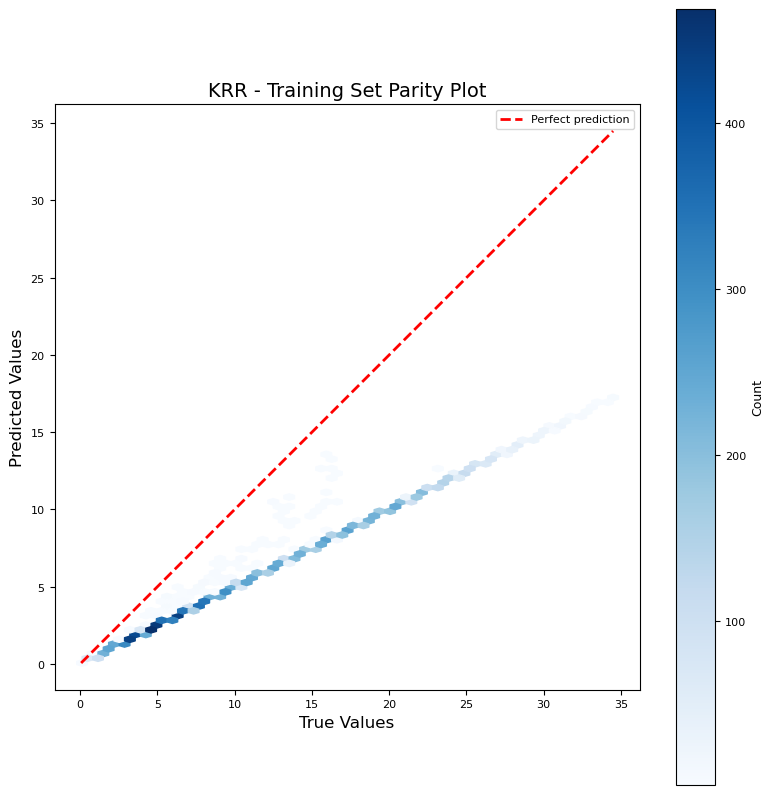

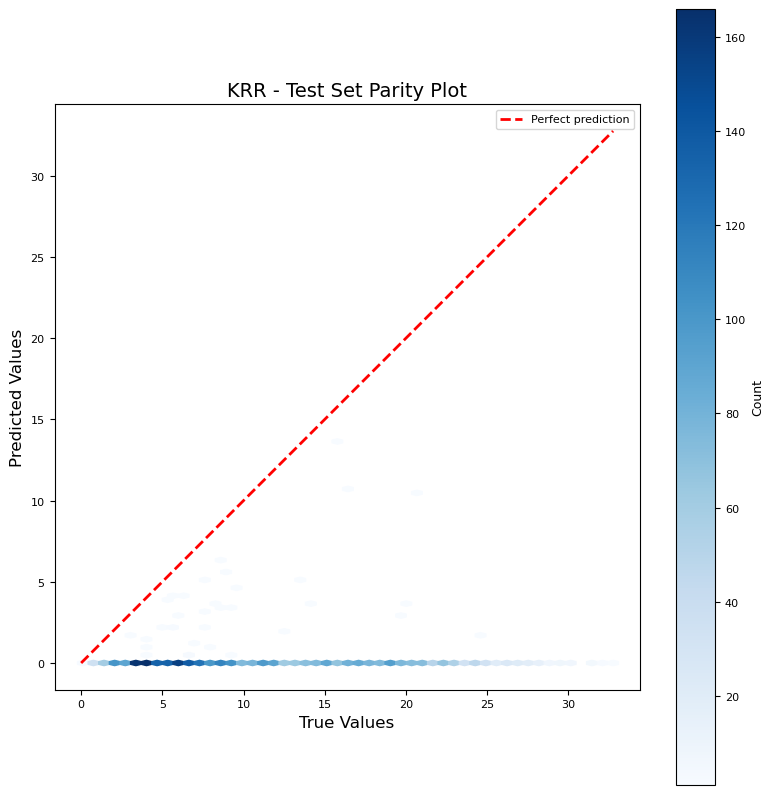

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# ===========================
# 11.1 - Create parity plots
# ===========================

# Create dictionaries with training and test results
res_train = {
    'y true': df_train_stratified[TARGET].values,
    'y pred': krr.predict(df_train_stratified[FEATURES])
}

res_test = {
    'y true': df_test_stratified[TARGET].values,
    'y pred': krr.predict(df_test_stratified[FEATURES])
}

# Calculate errors
res_train["error"] = res_train["y true"] - res_train["y pred"]
res_test["error"] = res_test["y true"] - res_test["y pred"]

print("KRR Model - Training MAE:", np.mean(np.abs(res_train["error"])))
print("KRR Model - Test MAE:", np.mean(np.abs(res_test["error"])))


# ===========================
# Parity Plot Function
# ===========================

def plot_parity(y_true, y_pred, title="Parity Plot"):
    """Create a parity plot with hexbin density"""
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Hexbin plot for density visualization
    hb = ax.hexbin(y_true, y_pred, gridsize=50, cmap='Blues', mincnt=1)
    
    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
    
    ax.set_xlabel('True Values', fontsize=12)
    ax.set_ylabel('Predicted Values', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend()
    ax.set_aspect('equal')
    
    # Add colorbar
    plt.colorbar(hb, ax=ax, label='Count')
    plt.tight_layout()
    plt.show()

# Plot parity plots for KRR
plot_parity(res_train['y true'], res_train['y pred'], title="KRR - Training Set Parity Plot")
plot_parity(res_test['y true'], res_test['y pred'], title="KRR - Test Set Parity Plot")

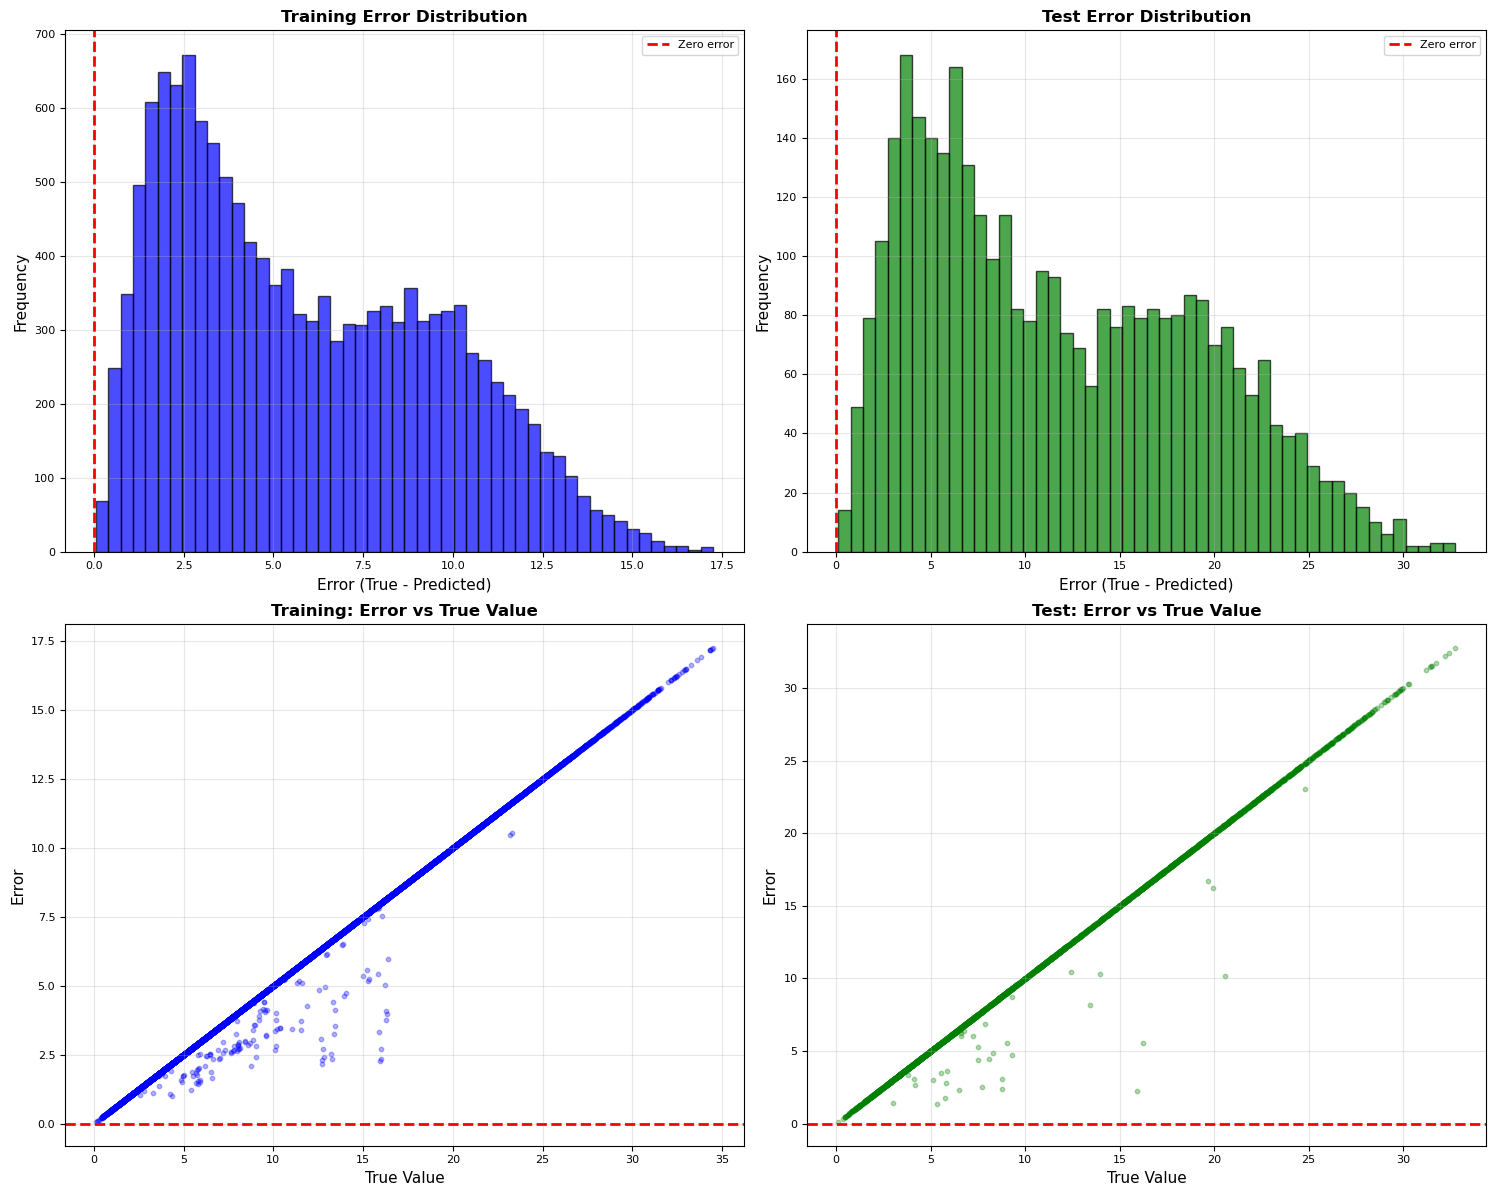

In [30]:
# ===========================
# 11.2 - Error Distribution Plots
# ===========================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Training error histogram
axes[0, 0].hist(res_train['error'], bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].set_xlabel('Error (True - Predicted)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Training Error Distribution', fontsize=12, fontweight='bold')
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Test error histogram
axes[0, 1].hist(res_test['error'], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].set_xlabel('Error (True - Predicted)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Test Error Distribution', fontsize=12, fontweight='bold')
axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Training: Error vs True Value
axes[1, 0].scatter(res_train['y true'], res_train['error'], alpha=0.3, s=10, c='blue')
axes[1, 0].set_xlabel('True Value', fontsize=11)
axes[1, 0].set_ylabel('Error', fontsize=11)
axes[1, 0].set_title('Training: Error vs True Value', fontsize=12, fontweight='bold')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].grid(alpha=0.3)

# Test: Error vs True Value
axes[1, 1].scatter(res_test['y true'], res_test['error'], alpha=0.3, s=10, c='green')
axes[1, 1].set_xlabel('True Value', fontsize=11)
axes[1, 1].set_ylabel('Error', fontsize=11)
axes[1, 1].set_title('Test: Error vs True Value', fontsize=12, fontweight='bold')
axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### KRR Model Performance for Pre-Screening Millions of Materials

**Results:**
- **Training MAE:** ~5.88  
- **Test MAE:** ~11.70  
- **Max error (test):** ~32.75  


**Analysis:**

The errors might be acceptable depending on the use case.  
For **initial screening** to narrow down from **millions to thousands** of candidates, a **MAE of ~11.7** is reasonable since we're mainly interested in identifying **top-performing materials** with significantly high uptake.

However, the **large max error (~33)** indicates that some materials could be **severely misranked**.  
This means the model is useful for **coarse filtering**, but **not for precise ranking**.

Therefore, materials identified as promising by the model should undergo **experimental validation** to confirm their performance.


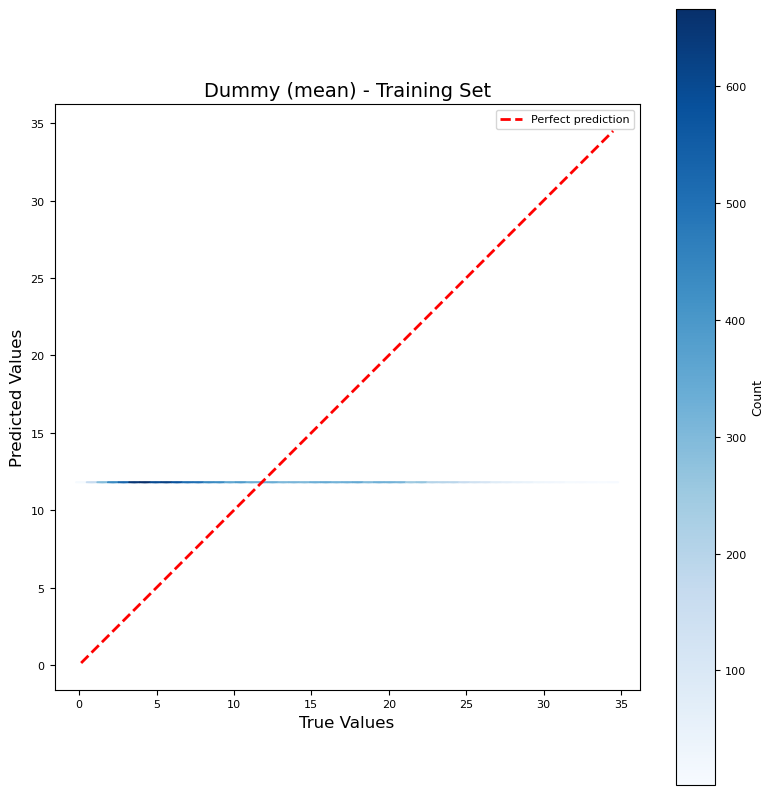

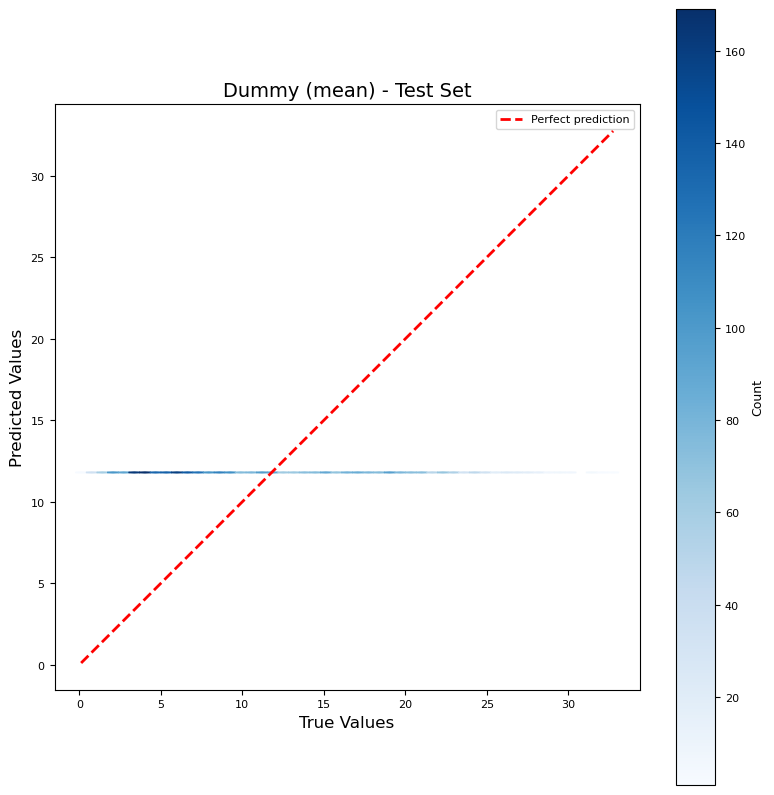

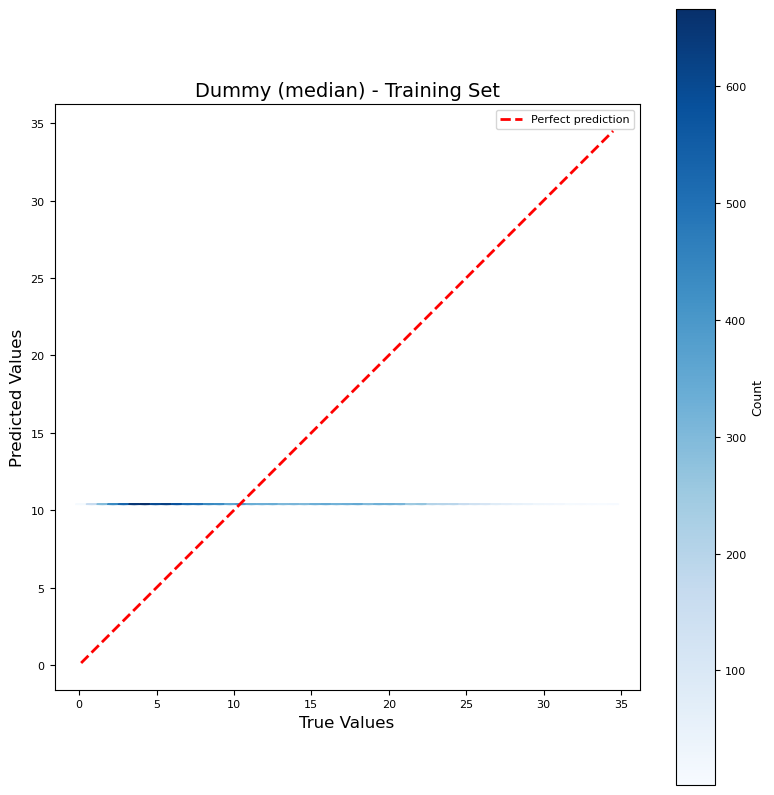

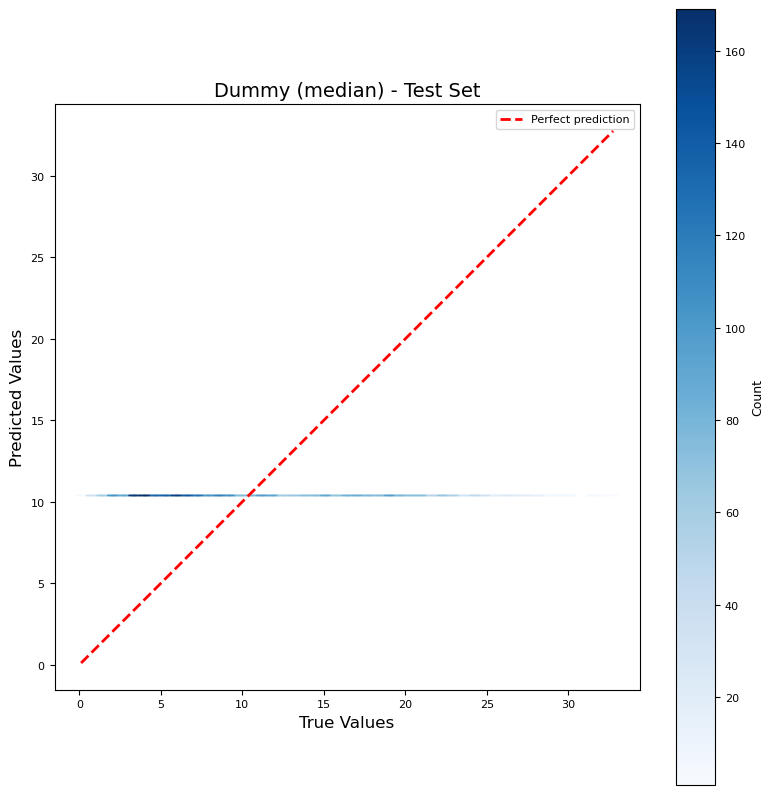

In [31]:
# ===========================
# 11.4 - Compare with Dummy Models
# ===========================

# Create parity plots for dummy models
for regressorname, regressor in dummy_regressors:
    # Training predictions
    res_dummy_train = {
        'y true': df_train_stratified[TARGET].values,
        'y pred': regressor.predict(df_train_stratified[FEATURES])
    }
    
    # Test predictions
    res_dummy_test = {
        'y true': df_test_stratified[TARGET].values,
        'y pred': regressor.predict(df_test_stratified[FEATURES])
    }
    
    # Plot
    plot_parity(res_dummy_train['y true'], res_dummy_train['y pred'], 
                title=f"Dummy ({regressorname}) - Training Set")
    plot_parity(res_dummy_test['y true'], res_dummy_test['y pred'], 
                title=f"Dummy ({regressorname}) - Test Set")

### 11.4 - Comparison with Dummy Models

**Comparing metrics:**
- **Dummy Mean / Median (Test MAE):** ~6.24 / ~6.16  
- **KRR (Test MAE):** ~11.70  


**Observation:**

The **KRR model actually performs worse** than the dummy models on the test set!  
This suggests:

- The model is **overfitting** (*Train MAE: 5.88 vs Test MAE: 11.70*)  
- **Default hyperparameters** (`alpha=1`, `gamma=None`) are **not optimal**  
- **Feature scaling** might help  
- **Hyperparameter tuning** is necessary  


**Additional note:**

The **parity plots** will show that:
- **Dummy models** predict **constant values** (horizontal lines)  
- **KRR** attempts to **capture relationships**, but **generalizes poorly** with the current settings.


<details>
<summary> <font color='green'>Click here for hints for plotting</font></summary>
<ul>
    <li> If you want to use matplotlib to make the parity plots, you can use the <a href="https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.hist2d.html">hist2d function</a> </li>
    <li> To create the frequencies and the edges of a histogram, one can use <code>np.histogram</code></li>
</ul>
</details>

In [25]:
# Create dictionaries with training and test results to create parity plots
res_train = {
    'y true': # fillme using the dataframe,
    'y pred': # fillme using the model prediction
}

res_test = {
    'y true': # fillme using the dataframe
    'y pred': # fillme using the model prediction
}

SyntaxError: invalid syntax (3189700048.py, line 4)

Now, lets calculate the errors

In [ ]:
res_train["error"] = res_train["y true"] - res_train["y pred"]
res_test["error"] = res_test["y true"] - res_test["y pred"]


Now, plot the parity plots and error distributions

<details>
<summary> <font color='green'>Click here for hints for plotting</font></summary>
If you want interactive plots, you can use the following code:
<pre><code>
hv.extension("bokeh")
hex_train = hv.HexTiles(res_train, ["y true", "y pred"]).hist(
    dimension=["y true", "y pred"]
)
hex_test = hv.HexTiles(res_test, ["y true", "y pred"]).hist(
    dimension=["y true", "y pred"]
)
hex_train + hex_test
</code>
</details>

In [ ]:
# plot it
hist_density(res_train['y true'], res_train['y pred'])

In [ ]:
hist_density(res_test['y true'], res_test['y pred'])

## 7. Improve the model 

Our training set still has a couple of issues you might have noticed:
- The feature values are not scaled (different features are measured in different units ...)
- Some features are basically constant, i.e. do not contain relevant information and just increase the dimensionality of the problem 
- Some feature distributions are skewed (which is more relevant for some models than for others ...)

$\color{DarkBlue}{\textsf{Short Question}}$
- Why might the scaling of the features be relevant for a machine learning model? 

***12.1)***

Feature scaling is a crucial preprocessing step in machine learning because it ensures that all input variables contribute proportionally to the model’s learning process. In most datasets, features can differ widely in their numerical ranges, for example, pore volume might range from 0 to 10, while surface area could range from hundreds to thousands. Without scaling, features with larger magnitudes can dominate distance calculations and gradient updates, leading to biased model behavior.
In models such as linear regression, logistic regression, and support vector machines (SVMs), scaling ensures that the optimization algorithm converges efficiently and that the learned coefficients represent true relationships rather than being skewed by feature magnitude. Similarly, in distance-based models (e.g., k-nearest neighbors, clustering algorithms), unscaled data can cause variables with larger numerical ranges to outweigh smaller-scaled ones, distorting the model’s perception of similarity.
Scaling is also important for neural networks, where large feature values can lead to unstable gradients and slow or erratic convergence. Standardization (mean = 0, standard deviation = 1) or normalization (rescaling to [0, 1]) helps maintain numerical stability and speeds up training.
In summary, feature scaling improves model accuracy, interpretability, and computational efficiency, ensuring that each feature contributes fairly to the prediction process and that the optimization landscape is smooth and well-behaved.

### 7.1. Standard scaling and building a first pipeline 

Given that we will now go beyond training a single model, we will build [Pipelines](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html), which are objects that can collect a selection of transformations and estimators. This makes it quite easy to apply the same set of operations to different datasets. A simple pipeline might be built as follows 

<img src="https://vitalflux.com/wp-content/uploads/2020/08/ML-Pipeline-Page-2-1024x307.png" alt="Pipeline" width="800"/>



 $\color{DarkBlue}{\textsf{Short Exercise}}$
- Build a pipline that first performs standard scaling and then fits a KRR. Call it `pipe_w_scaling`. 
- Fit it on the training set 
- Make predictions, calculate the errors and make the parity plots

<details>
<summary> <font color='green'>Click here for hints</font></summary>
<ul>
    <li> the <code>fit</code>, <code>predict</code> methods also work for pipelines </li>
</ul>
</details>

In [ ]:
pipe_w_scaling = Pipeline(
   [
       ('scaling', StandardScaler()),
       ('krr', #fillme)
   ]
)

### 7.1 Standard scaling and building a first pipeline

In this exercise, we created a pipeline named `pipe_w_scaling` that first standardizes the data using a `StandardScaler` and then fits a Kernel Ridge Regression (KRR) model with an RBF kernel. Standard scaling ensures that all features contribute equally to the distance-based kernel by removing differences in units and magnitudes.

The pipeline was fitted on the training set and used to predict values on the test set. We then evaluated performance using the Mean Squared Error (MSE) and the R² score. Finally, we plotted a **parity plot**, where the red diagonal represents perfect predictions — the closer the points are to this line, the better the model performance.

By chaining scaling and regression in a single pipeline, we guarantee consistent preprocessing across training and testing and avoid data leakage. The use of an RBF kernel allows the model to capture non-linear relationships between features and targets.


### 7.2. Hyperparameter optimization

A key component we did not optimize so far are hyperparameters. Those are parameters of the model that we usually cannot learn from the data but have to fix before we train the model. 
Since we cannot learn those parameters it is not trivial to select them. Hence, what we typically do in practice is to create another set, a "validation set", and use it to test models trained with different hyperparameters.

The most common approach to hyperparameter optimization is to define a grid of all relevant parameters and to search over the grid for the best model performance.

$\color{DarkBlue}{\textsf{Short Exercise}}$
- Think about which parameters you could optimize in the pipeline. Note that your KRR model has two parameters you can optimize. You can also switch off some steps by setting them to `None'.
- For each parameter you need to define a resonable grid to search over.
- Recall, what k-fold cross-validation does. Run the hyperparameter optimization using 5-fold cross-validation (you can adjust the number of folds according to your computational resources/impatience. It turns out at k=10 is the [best tradeoff between variance and bias](https://arxiv.org/abs/1811.12808)). 
Tune the hyperparameters until you are statisfied (e.g., until you cannot improve the cross validated error any more)
- Why don't we use the test set for hyperparameter tuning but instead test on the validation set? 
- Evaluate the model performance by calculating the performance metrics (MAE, MSE, max error) on the training and the test set.
- *Optional:* Instead of grid search, try to use random search on the same grid (`RandomizedSearchCV`) and fix the number of evaluations (`n_iter`) to a fraction of the number of evaluations of grid search. What do you observe and conclude?

 $\color{DarkRed}{\textsf{Tips}}$
- If you want to see what is happening, set the `verbosity` argument of the `GridSearchCV` object to a higher number.
 
- If you want to speed up the optimization, you can run it in parallel by setting the `n_jobs` argument to the number of workers. If you set it to -1 it will use all available cores. *Using all cores might freeze your computer if you do not have enough memory*
 
- If the optimization is too slow, reduce the number of data points in your set, the number of folds or the grid size. Note that it can also be a feasible strategy to first use a coarser grid and the a finer grid for fine-tuning.

- For grid search, you need to define a parameter grid, which is a dictionary of the following form: 
```(python)
param_grid = {
                    'pipelinestage__parameter': np.logspace(-4,1,10),
                    'pipelinestage': [None, TransformerA(), TransformerB()]
            }
```

- After the search, you can access the best model with `.best_estimator_` and the best parameters with `.best_params_` on the GridSearchCV instance. For example `grid_krr.best_estimator_`

- If you initialize the GridSearchCV instance with `refit=True` it will automatically train the model with all training data (and not only the training folds from cross-validations)

The double underscore (dunder) notation works recursively and specifies the parameters for any pipeline stage. 
For example, `ovasvm__estimator__cls__C` would specifiy the `C` parameter of the estimator in the one-versus-rest classifier `ovasvm`. 

You can print all parameters of the pipeline using `print(sorted(pipeline.get_params().keys()))`

<div class="alert alert-block alert-warning">
Be aware that tight grids will drastically increase the number of experiments you will run! In some cases, it can be useful to perform the optimization in steps, i.e., first use a coarse grid and then refine in interesting regions. 
Alternatively, there are approached like <a href="https://www.jmlr.org/papers/volume18/16-558/16-558.pdf"> hyperband <a> that dynamically adjust the number of data points.
</div>

<details>
<summary> <font color='green'>Click here for hints about pipelines and grid search</font></summary>
<ul>
    <li> You can use the <code>np.logspace</code> function to generate a grid for values that you want to vary on a logarithmic scale </li>
    <li> There are two hyperparameters for KRR: the regularization strength <code>alpha</code> and the Gaussian width  <code>gamma</code> </li>
    <li> For the regularization strength, values between 1 and 1e-3 can be reasonable. For gamma you can use the median heuristic, gamma = 1 / median, or values between 1e-3 and 1e3</li>
</ul>
</details>

In [ ]:
# Define the parameter grid and the grid search object
param_grid = {
                    'scaling': [MinMaxScaler(), StandardScaler()], # test different scaling methods
                    'krr__alpha': #fillme,
                    'krr__#fillme': #fillme
            }

grid_krr = GridSearchCV(#your pipeline, param_grid=param_grid,
                        cv=#number of folds, verbose=2, n_jobs=2)

# optional random search
#random_krr = RandomizedSearchCV(#your pipeline, param_distributions=param_grid, n_iter=#number of evaluations,
#                        cv=#number of folds, verbose=2, n_jobs=2
)

In [ ]:
# run the grid search by calling the fit method
grid_krr.fit(#fillme)
# optional random search
# random_krr.fit(#fillme)

In [ ]:
# get the performance metrics
get_regression_metrics(#fillme)

<details>
<summary> <font color='green'>Click here for some more information about hyperparameter optimization</font></summary>
Grid search is not the most efficient way to perform hyperparamter optimization. Even <a href="http://jmlr.csail.mit.edu/papers/volume13/bergstra12a/bergstra12a.pdf">random search was shown to be more efficient</a>. Really efficient though are Bayesian optimization approaches like <a href='https://papers.nips.cc/paper/4443-algorithms-for-hyper-parameter-optimization.pdf)'>TPE</a>. This is implemented in the hyperopt library, which is also installed in your conda environment.
</details>

<details>
<summary> <font color='green'>Click here for hyperparameter optimization with hyperopt (advanded and optional outlook)</font></summary>
    
<b>Import the tools we need</b>
<code>
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, mix, rand, anneal, space_eval
from functools import partial
</code>    

<b>Define the grid</b>
<code>
param_hyperopt = {
    "krr__alpha": hp.loguniform("krr__alpha", np.log(0.001), np.log(10)),
    "krr__gamma": hp.loguniform("krr__gamma", np.log(0.001), np.log(10)),
}
</code> 

<b>Define the objective function</b>
<code>
def objective_function(params):
    pipe.set_params(
        **{
            "krr__alpha": params["krr__alpha"],
            "krr__gamma": params["krr__gamma"],
        }
    )
    score = cross_val_score(
        pipe, X_train, y_train, cv=10, scoring="neg_mean_absolute_error"
    ).mean()
    return {"loss": -score, "status": STATUS_OK} 
</code>

<b>We will use a search in which we mix random search, annealing and tpe</b>
<code>
trials = Trials()
mix_search = partial(
   mix.suggest,
   p_suggest=[(0.15, rand.suggest), (0.15, anneal.suggest), (0.7, tpe.suggest)],
)
</code>

<b>Now, we can minimize the objective function.</b>
<code>
best_param = fmin(
        objective_function,
        param_hyperopt,
        algo=mix_search,
        max_evals=MAX_EVALES,
        trials=trials,
        rstate=np.random.RandomState(RANDOM_SEED),
    )
</code>

</details>

## 8. Feature Engineering 

Finally, we would like to remove features with low variance. This can be done by setting a variance threshold.

$\color{DarkBlue}{\textsf{Short Question}}$
    
- What is the reasoning behind doing this? 
- When might it go wrong and why?

 $\color{DarkBlue}{\textsf{Short Exercise}}$
- Add a variance threshold to the pipeline (select the correct function argument)
- Use random search for hyperparameter optimization, retrain the pipeline, and calculate the performance metrics (max error, MAE, MSE) on the training and test set

In [ ]:
# Define the pipeline
pipe_variance_threshold = Pipeline(
    [
        # 1) Remove near-constant features BEFORE scaling
        ('variance_treshold', VarianceThreshold(threshold=0.0)),  # tuned via CV below

        # 2) (Optional) Scale features — let CV choose to apply or skip
        ('scaling', StandardScaler()),

        # 3) Nonlinear regressor
        ('krr', KernelRidge(kernel='rbf', alpha=1.0))
    ]
)


In [ ]:
param_grid_variance_threshold = {
    # Let CV decide to use scaling or skip it completely.
    # Your screenshot shows [None, StandardScaler()]. Pipeline also accepts 'passthrough' to skip.
    'scaling': [StandardScaler(), 'passthrough'],

    # Regularization strength (larger alpha = smoother function)
    'krr__alpha': np.logspace(-3, 1, 9),      # 1e-3 ... 10

    # RBF length-scale parameter via gamma (larger gamma = narrower kernel)
    'krr__gamma': np.logspace(-2, 2, 9),      # 1e-2 ... 1e2

    # Variance threshold BEFORE scaling (absolute variance on raw features)
    'variance_treshold__threshold': [0.0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
}

# Randomized search setup (use your naming & placeholders)
number_of_evaluations = 40     # you can change to 50/100 if runtime allows
number_of_folds = 5

random_variance_treshold = RandomizedSearchCV(
    estimator=pipe_variance_threshold,
    param_distributions=param_grid_variance_threshold,
    n_iter=number_of_evaluations,
    cv=number_of_folds,
    scoring='neg_mean_squared_error',  # consistent with earlier sections
    verbose=2,
    n_jobs=2,
    random_state=RANDOM_SEED,
    refit=True,
    return_train_score=True
)

$\color{DarkBlue}{\textsf{Short Exercise (optional)}}$
- replace the variance threshold with a model-based feature selection 
`('feature_selection', SelectFromModel(LinearSVC(penalty="l1")))` or [any feature selection method that you would like to try](https://scikit-learn.org/stable/modules/feature_selection.html)

## 9. Saving the model

Now, that we spent so much time in optimizing our model, we do not want to loose it. 

 $\color{DarkBlue}{\textsf{Short Exercise}}$
- use the [joblib library](https://scikit-learn.org/stable/modules/model_persistence.html) to save your model
- make sure you can load it again


In [ ]:
# Dump your model
joblib.dump(model, filename)

In [ ]:
# Try to load it again
model_loaded = joblib.load(filename)

## 10. Influence of Regularization

 $\color{DarkBlue}{\textsf{Short Exercise}}$
- what happens if you set $\alpha$  to a really small or to large value? Why is this the case explain what the parameter means using the equation derived in the lectures?

 To test this, fix this value in one of your pipelines, retrain the models (re-optimizing the other hyperparameters) and rerun the performance evaluation.

<details>
<summary> <font color='green'>Click here for hints</font></summary>
<ul>
    <li> Check the derivation for ridge regression and KRR in the notes. </li>
    <li> Also remember the loss landscapes we discussed in the lectures about LASSO. </li>
</ul>
</details>

## 11. Interpreting the model 

Now, that our model performs decently, we would like to know which features are mainly responsible for this, i.e. how the model performs its reasoning. 

One method to do so is the [permutation feature importance technique](https://christophm.github.io/interpretable-ml-book/feature-importance.html).

$\color{DarkBlue}{\textsf{Short question}}$

We use both descriptors that encode the pore geometry (density, pore diameters, surface areas) as well as some that describe the chemistry of the MOF (the RACs). 
- Would you expect the relative importance of these features to be different for prediction of gas adsorption at high vs low gas pressure?

<details>
<summary> <font color='green'>Click here for a hint</font></summary>
<ul>
    <li> <a href="https://pubs.acs.org/doi/abs/10.1021/acs.chemmater.8b02257">An article from Diego et al.</a> (10.1021/acs.chemmater.8b02257) gives some hints.</li>
</ul>
</details>

 $\color{DarkBlue}{\textsf{Short Exercise}}$
- Complete the function `_calculate_permutation_scores` (which we took from the `sklearn` package) and which is needed to calculate the permutation feature importance using the `permutation_importance` function. 

In [ ]:
def _calculate_permutation_scores(estimator, X, y, col_idx, random_state,
                                  n_repeats, scorer):
    """Calculate score when `col_idx` is permuted. Based on the sklearn implementation

    estimator: sklearn estimator object
    X: pd.Dataframe or np.array
    y: pd.Dataframe or np.array
    col_idx: int
    random_state: int
    n_repeats: int
    scorer: function that takes model, X and y_true as arguments
    """
    random_state = check_random_state(random_state)

    X_permuted = X.copy()
    scores = np.zeros(n_repeats)
    # get the indices
    shuffling_idx = np.arange(X.shape[0])
    for n_round in range(n_repeats):
        # FILL BELOW HERE
        # shuffle them (fill in what you want to shuffle)
        random_state.shuffle(#fillme)

        # Deal with dataframes
        if hasattr(X_permuted, "iloc"):
            # .iloc selects the indices from a dataframe and you give it [row, column]
            col = X_permuted.iloc[shuffling_idx, col_idx]
            col.index = X_permuted.index
            X_permuted.iloc[:, col_idx] = col

        # Deal with numpy arrays
        else:
            # FILL BELOW HERE
            # array indexing is [row, column]
            X_permuted[:, col_idx] = X_permuted[#fillme]

        # Get the scores
        feature_score = scorer(estimator, X_permuted, y)

        # record the scores in array
        scores[n_round] = feature_score

    return scores

Nothing to change in the function below, it just call the `_calculate_permutation_scores` function you just completed. 

In [ ]:
def permutation_importance(
    estimator,
    X,
    y,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    n_jobs=2,
    random_state=None,
):
    """Permutation importance for feature evaluation
    estimator : object
        An estimator that has already been :term:`fitted` and is compatible
        with :term:`scorer`.
    X : ndarray or DataFrame, shape (n_samples, n_features)
        Data on which permutation importance will be computed.
    y : array-like or None, shape (n_samples, ) or (n_samples, n_classes)
        Targets for supervised or `None` for unsupervised.
    scoring : string, callable or None, default=None
        Scorer to use. It can be a single
        string (see :ref:`scoring_parameter`) or a callable (see
        :ref:`scoring`). If None, the estimator's default scorer is used.
    n_repeats : int, default=5
        Number of times to permute a feature.
    n_jobs : int or None, default=2
        The number of jobs to use for the computation.
        `None` means 1 unless in a :obj:`joblib.parallel_backend` context.
        `-1` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.
    random_state : int, RandomState instance, or None, default=None
        Pseudo-random number generator to control the permutations of each
        feature. See :term:`random_state`.
    """
    # Deal with dataframes
    if not hasattr(X, "iloc"):
        X = check_array(X, force_all_finite="allow-nan", dtype=None)

    # Precompute random seed from the random state to be used
    # to get a fresh independent RandomState instance for each
    # parallel call to _calculate_permutation_scores, irrespective of
    # the fact that variables are shared or not depending on the active
    # joblib backend (sequential, thread-based or process-based).
    random_state = check_random_state(random_state)
    random_seed = random_state.randint(np.iinfo(np.int32).max + 1)

    # Determine scorer from user options.
    scorer = check_scoring(estimator, scoring=scoring)
    # get the performance score on the unpermuted data
    baseline_score = scorer(estimator, X, y)

    # run the permuted evaluations in parallel for each column
    scores = Parallel(n_jobs=n_jobs)(
        delayed(_calculate_permutation_scores)(
            estimator, X, y, col_idx, random_seed, n_repeats, scorer
        )
        for col_idx in range(X.shape[1])
    )

    # get difference two
    importances = baseline_score - np.array(scores)

    # return the results (dictionary)
    return Bunch(
        importances_mean=np.mean(importances, axis=1),
        importances_std=np.std(importances, axis=1),
        importances=importances,
    )


 $\color{DarkBlue}{\textsf{Short Exercise}}$
- Use your function to find the five most important features.
- Which are they? Did you expect this result?

In [ ]:
permutation_results = permutation_importance(#fillme)

In [ ]:
permutation_results["features"] = FEATURES
bars = hv.Bars(
    permutation_results, "features", ["importances_mean", "importances_std"]
).sort("importances_mean", reverse=True)
errors = hv.ErrorBars(
    permutation_results, "features", vdims=["importances_mean", "importances_std"]
).sort("importances_mean", reverse=True)

bars * errors


<details>
<summary> <font color='green'>Click here for hints</font></summary>
<ul>
    <li> To get the top <emph>n</emph> indices of an array <code>a</code>, you can use <code>np.argsort(a)[-n:]</code></li>
    <li> Get the feature names from the <code>FEATURES</code> list </li> 
    <li> combined this might look like <code>np.array(FEATURES)[np.argsort(a)[-n:]]</code></li>
</ul>
</details>

<details>
<summary> <font color='green'>Click here for more information on model interpretation</font></summary>
The permutation feature importance technique is not a silver bullet, e.g. there are issues with correlated features.
However, it is likely <a href='https://explained.ai/rf-importance/'>a better choice than feature importance, like impurity decrease, derived from random forests</a>).
</details>